<a href="https://colab.research.google.com/github/mrshivalavanga-code/Dissertation-Repo/blob/main/21_02_Need_Assignment_~Shiva_UEL__M10689.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Data handling libraries are imported
import pandas as pd
import numpy as np

# Data visualization libraries are imported
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries are imported
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression models are imported
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

# Evaluation metrics are imported
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Warning messages are ignored for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Red wine dataset is loaded
red = pd.read_csv('winequality-red.csv', sep=';')
red['wine_type'] = 0   # Red wine is encoded as 0

# White wine dataset is loaded
white = pd.read_csv('winequality-white.csv', sep=';')
white['wine_type'] = 1   # White wine is encoded as 1

# Both datasets are merged
data = pd.concat([red, white], axis=0)

# Dataset is shuffled
data = data.sample(frac=1, random_state=42)

# Index is reset
data.reset_index(drop=True, inplace=True)

# First few rows are displayed
print(data.head())

# Shape of dataset is displayed
print("Dataset Shape:", data.shape)

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.17         0.74            12.8      0.045   
1            7.7              0.64         0.21             2.2      0.077   
2            6.8              0.39         0.34             7.4      0.020   
3            6.3              0.28         0.47            11.2      0.040   
4            7.4              0.35         0.20            13.9      0.054   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 24.0                 126.0  0.99420  3.26       0.38   
1                 32.0                 133.0  0.99560  3.27       0.45   
2                 38.0                 133.0  0.99212  3.18       0.44   
3                 61.0                 183.0  0.99592  3.12       0.51   
4                 63.0                 229.0  0.99888  3.11       0.50   

   alcohol  quality  wine_type  
0     12.2        8          1  
1      9.9        5 

In [ ]:
# Data types of each column are displayed
print(data.dtypes)

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
wine_type                 int64
dtype: object


In [ ]:
# Summary statistics are generated
print(data.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    6497.000000       6497.000000  6497.000000     6497.000000   
mean        7.215307          0.339666     0.318633        5.443235   
std         1.296434          0.164636     0.145318        4.757804   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.400000          0.230000     0.250000        1.800000   
50%         7.000000          0.290000     0.310000        3.000000   
75%         7.700000          0.400000     0.390000        8.100000   
max        15.900000          1.580000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  6497.000000          6497.000000           6497.000000  6497.000000   
mean      0.056034            30.525319            115.744574     0.994697   
std       0.035034            17.749400             56.521855     0.002999   
min       0.009000             1.000000         

In [ ]:
# Missing values are checked
print(data.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64


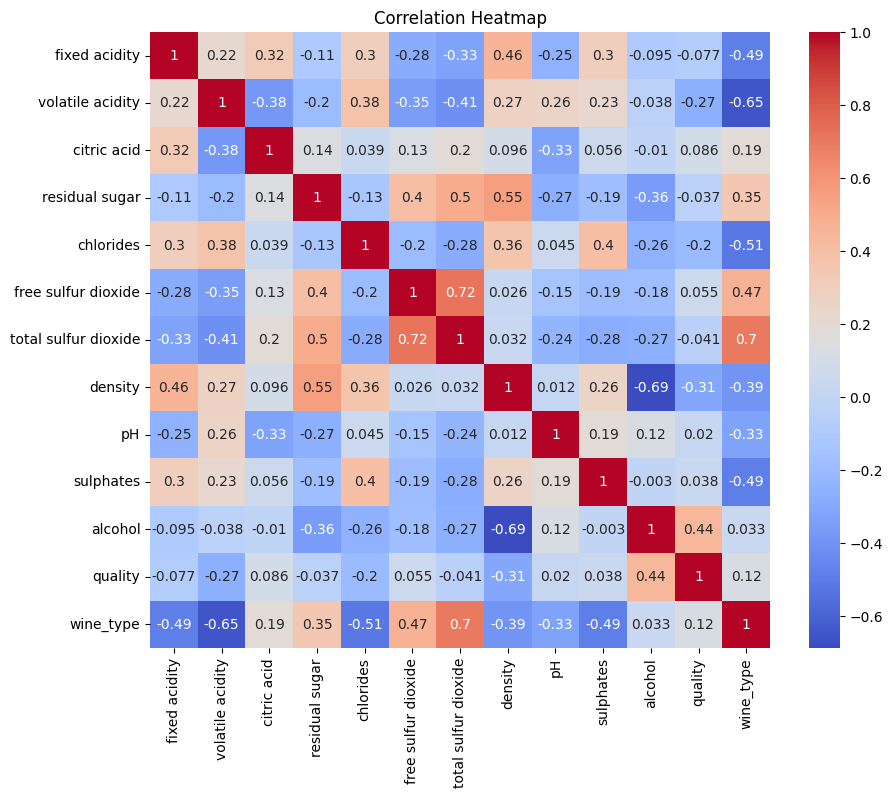

In [ ]:
# Correlation matrix is created
corr_matrix = data.corr()

# Heatmap is plotted
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

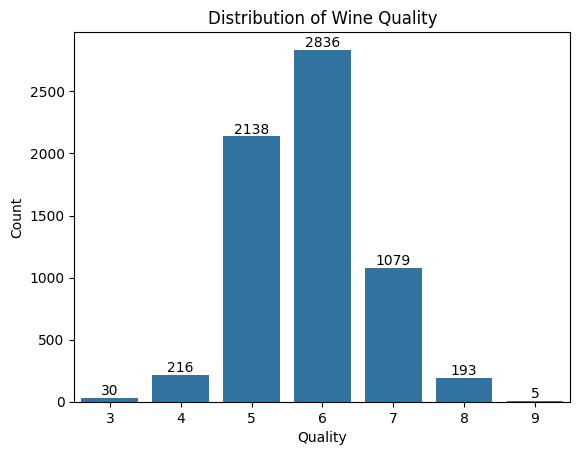

In [ ]:
# Distribution of wine quality with values
plt.figure()
ax = sns.countplot(x='quality', data=data)

# Adding values on top of bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.title("Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

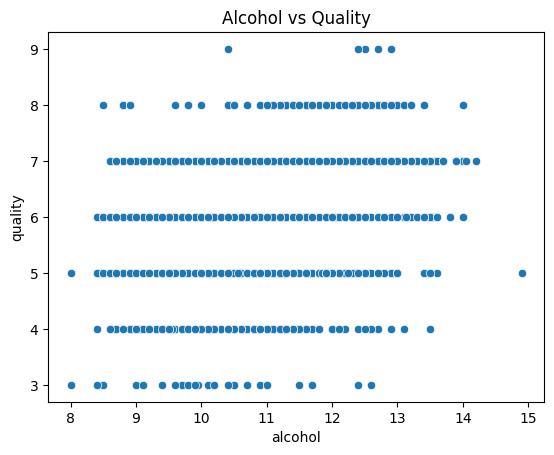

In [ ]:
# Alcohol vs Quality relationship
plt.figure()
sns.scatterplot(x='alcohol', y='quality', data=data)
plt.title("Alcohol vs Quality")
plt.show()

In [ ]:
# Mean is calculated
mean_values = data.mean()

# Median is calculated
median_values = data.median()

# Mode is calculated
mode_values = data.mode().iloc[0]

print("Mean:\n", mean_values)
print("\nMedian:\n", median_values)
print("\nMode:\n", mode_values)

Mean:
 fixed acidity             7.215307
volatile acidity          0.339666
citric acid               0.318633
residual sugar            5.443235
chlorides                 0.056034
free sulfur dioxide      30.525319
total sulfur dioxide    115.744574
density                   0.994697
pH                        3.218501
sulphates                 0.531268
alcohol                  10.491801
quality                   5.818378
wine_type                 0.753886
dtype: float64

Median:
 fixed acidity             7.00000
volatile acidity          0.29000
citric acid               0.31000
residual sugar            3.00000
chlorides                 0.04700
free sulfur dioxide      29.00000
total sulfur dioxide    118.00000
density                   0.99489
pH                        3.21000
sulphates                 0.51000
alcohol                  10.30000
quality                   6.00000
wine_type                 1.00000
dtype: float64

Mode:
 fixed acidity             6.8000
volatile acidit

In [ ]:
# Input features (X) are separated
X = data.drop('quality', axis=1)

# Target variable (y) is separated
y = data['quality']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (6497, 12)
Target Shape: (6497,)


In [ ]:
# Correlation of all features with target variable
corr_with_target = data.corr()['quality'].sort_values(ascending=False)

print(corr_with_target)

quality                 1.000000
alcohol                 0.444319
wine_type               0.119323
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64


In [ ]:
# Selecting features with correlation greater than 0.05 (absolute value)
selected_features = corr_with_target[abs(corr_with_target) > 0.05].index

print("Selected Features:", selected_features)

Selected Features: Index(['quality', 'alcohol', 'wine_type', 'citric acid', 'free sulfur dioxide',
       'fixed acidity', 'chlorides', 'volatile acidity', 'density'],
      dtype='object')


In [ ]:
# Removing 'quality' from selected features
selected_features = selected_features.drop('quality')

In [ ]:
# Final input features
X = data[selected_features]

# Target variable
y = data['quality']

print("Final Feature Columns:\n", X.columns)
print("Feature Shape:", X.shape)

Final Feature Columns:
 Index(['alcohol', 'wine_type', 'citric acid', 'free sulfur dioxide',
       'fixed acidity', 'chlorides', 'volatile acidity', 'density'],
      dtype='object')
Feature Shape: (6497, 8)


In [ ]:
# StandardScaler is initialized
scaler = StandardScaler()

# Features are scaled
X_scaled = scaler.fit_transform(X)

# Scaled features are displayed (first 5 rows)
print(X_scaled[:5])

[[ 1.43230805  0.57136659  2.89984453 -0.36766435 -0.16608919 -0.31497507
  -1.0306286  -0.16563062]
 [-0.49621913 -1.75018984 -0.74761336  0.0830898   0.37389511  0.59850404
   1.82436558  0.3012785 ]
 [ 1.26461004  0.57136659  0.14704613  0.42115542 -0.32037042 -1.02863062
   0.30575165 -0.85932416]
 [-0.83161516  0.57136659  1.04170561  1.71707362 -0.70607349 -0.45770618
  -0.36243847  0.40800058]
 [-1.3347092   0.57136659 -0.81643332  1.82976216  0.14247327 -0.05805907
   0.06277343  1.39517985]]


In [ ]:
# Dataset is split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Shapes are displayed
print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Feature Shape: (5197, 8)
Testing Feature Shape: (1300, 8)
Training Target Shape: (5197,)
Testing Target Shape: (1300,)


In [ ]:
# Linear Regression model is initialized
lr_model = LinearRegression()

# Model is trained using training data
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# SVR model is initialized
svr_model = SVR(kernel='rbf')

# Model is trained using training data
svr_model.fit(X_train, y_train)

SVR()

In [ ]:
# Predictions are generated using Linear Regression
y_pred_lr = lr_model.predict(X_test)

# First few predictions are displayed
print("Linear Regression Predictions:\n", y_pred_lr[:5])

Linear Regression Predictions:
 [5.83862399 5.59978806 6.39081562 5.48425795 6.0100511 ]


In [ ]:
# Predictions are generated using SVR
y_pred_svr = svr_model.predict(X_test)

# First few predictions are displayed
print("\nSVR Predictions:\n", y_pred_svr[:5])


SVR Predictions:
 [5.78951631 5.37151653 6.83701602 5.30751376 5.95682732]


In [ ]:
# MAE for Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)

# RMSE for Linear Regression
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression MAE: 0.5699585036236441
Linear Regression RMSE: 0.7426982959125243


In [ ]:
# MAE for SVR
mae_svr = mean_absolute_error(y_test, y_pred_svr)

# RMSE for SVR
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

print("\nSVR MAE:", mae_svr)
print("SVR RMSE:", rmse_svr)


SVR MAE: 0.5324691739657391
SVR RMSE: 0.7129453019080675


In [ ]:
# Model comparison is created using a dictionary
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'SVR'],
    'MAE': [mae_lr, mae_svr],
    'RMSE': [rmse_lr, rmse_svr]
})

print(model_comparison)

               Model       MAE      RMSE
0  Linear Regression  0.569959  0.742698
1                SVR  0.532469  0.712945


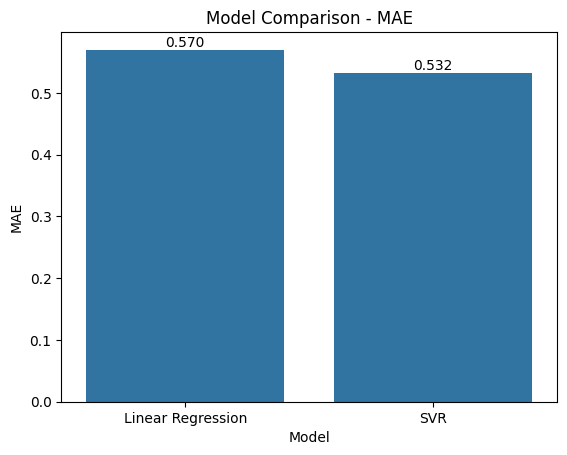

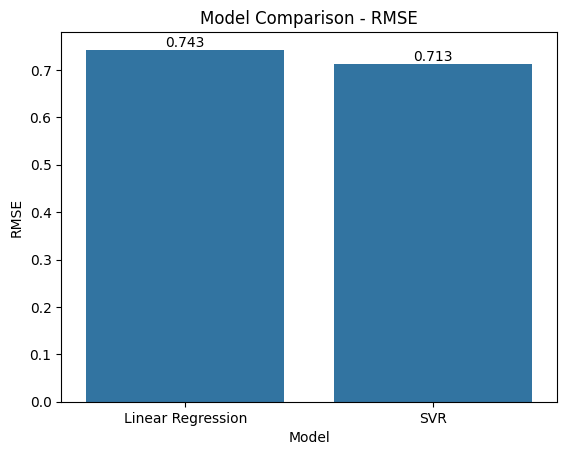

In [ ]:
plt.figure()
ax = sns.barplot(x='Model', y='MAE', data=model_comparison)

# Adding values on bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.3f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.show()

plt.figure()
ax = sns.barplot(x='Model', y='RMSE', data=model_comparison)

# Adding values on bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.3f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()

In [ ]:
# Coefficients from Linear Regression model
importance = lr_model.coef_

# Creating DataFrame for feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sorting values
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

               Feature  Importance
0              alcohol    0.457082
7              density    0.095286
3  free sulfur dioxide    0.066250
2          citric acid   -0.011742
5            chlorides   -0.027468
4        fixed acidity   -0.037484
1            wine_type   -0.122481
6     volatile acidity   -0.281169


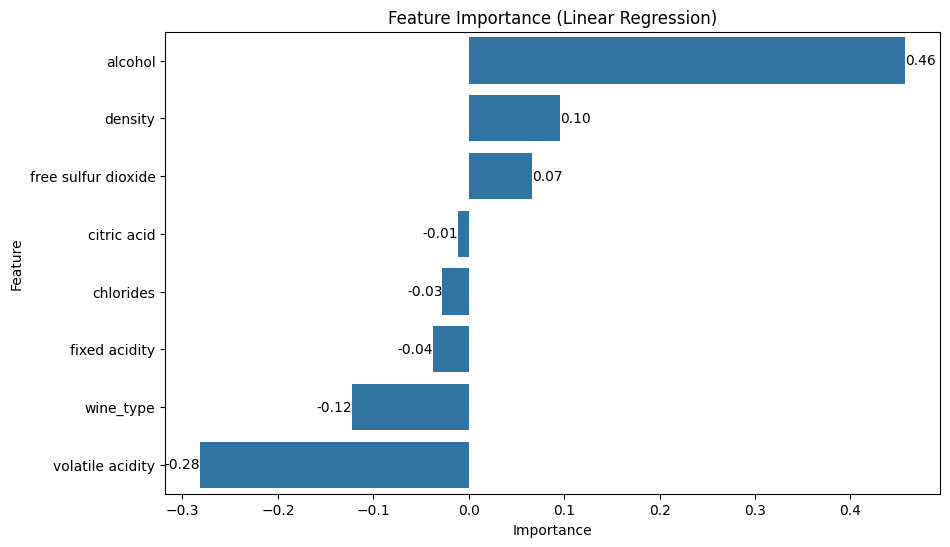

In [ ]:
# Bar plot with values
plt.figure(figsize=(10,6))
ax = sns.barplot(x='Importance', y='Feature', data=feature_importance)

# Adding values on bars
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f')

plt.title("Feature Importance (Linear Regression)")
plt.show()

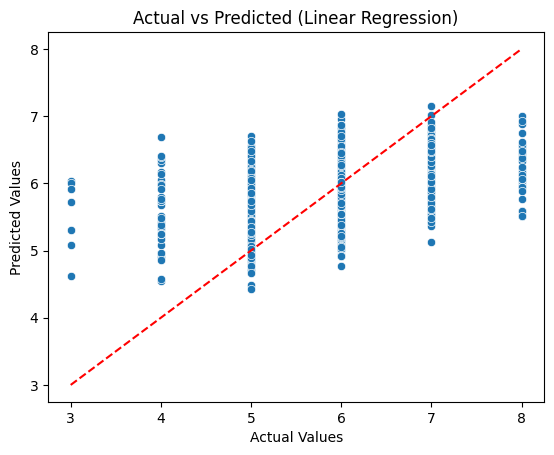

In [ ]:
# Actual vs Predicted Values (Linear Regression)
plt.figure()
ax = sns.scatterplot(x=y_test, y=y_pred_lr)

# Adding reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

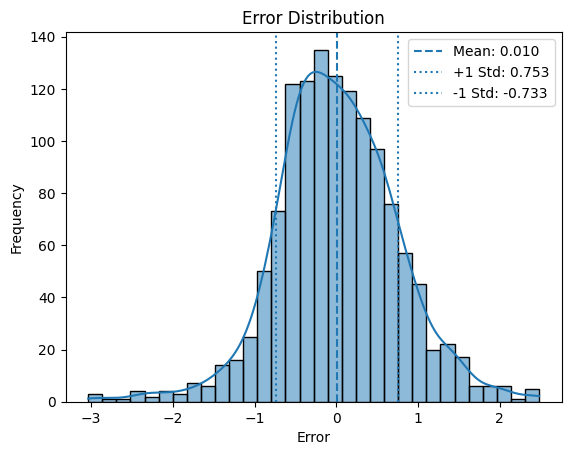

Mean Error: 0.010369668416495241
Standard Deviation: 0.7429116911635114


In [ ]:
# Errors are calculated
errors = y_test - y_pred_lr

# Mean and standard deviation are calculated
mean_error = errors.mean()
std_error = errors.std()

plt.figure()
ax = sns.histplot(errors, kde=True)

# Mean line
plt.axvline(mean_error, linestyle='--', label=f"Mean: {mean_error:.3f}")

# Standard deviation lines
plt.axvline(mean_error + std_error, linestyle=':', label=f"+1 Std: {(mean_error + std_error):.3f}")
plt.axvline(mean_error - std_error, linestyle=':', label=f"-1 Std: {(mean_error - std_error):.3f}")

# Labels and legend
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.legend()

plt.show()

# Printing values
print("Mean Error:", mean_error)
print("Standard Deviation:", std_error)